In [ ]:
if "BrentScheme" not in locals():
  !pip install "git+https://github.com/perryGabriel/brent-scheme.git"
from brentscheme import *
import torch
from tqdm import trange
factory = SchemaFactory()
printer = SchemeDisplay()
manipulator = SchemeManipulator()
stepper = Stepper()
trainer = Trainer()

In [ ]:
# printer.dump_tensors(scheme)

# Setup

In [ ]:
# @title Include Packages

import numpy as np
import matplotlib.pyplot as plt
from numpy.core.multiarray import ndarray
from tqdm import tqdm, trange

if 'jax' not in globals():
  !pip install jax jaxlib

import jax
import jax.numpy as jnp
from jax import grad

/tmp/ipython-input-2290027550.py:5: DeprecationWarning: numpy.core.multiarray is deprecated and has been renamed to numpy._core.multiarray. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.multiarray.ndarray.
  from numpy.core.multiarray import ndarray


In [ ]:
# @title Functions that do not need to be in a class

def download_file(n, p, number, scheme_or_diagram):
  from google.colab import files
  if scheme_or_diagram == 'scheme':
    files.download(f"{n}_{p}_e{number:.3f}_alpha.pkl")
    files.download(f"{n}_{p}_e{number:.3f}_beta.pkl")
    files.download(f"{n}_{p}_e{number:.3f}_gamma.pkl")
  if scheme_or_diagram == 'diagram':
    files.download(f'{n}_scheme_{p}_prod_{number:.3f}_best.png')

def delete_file(n, p, number, scheme_or_diagram):
  import os
  if scheme_or_diagram == 'scheme':
    os.remove(f"{n}_{p}_e{number:.3f}_alpha.pkl")
    os.remove(f"{n}_{p}_e{number:.3f}_beta.pkl")
    os.remove(f"{n}_{p}_e{number:.3f}_gamma.pkl")
  if scheme_or_diagram == 'diagram':
    os.remove(f'{n}_scheme_{p}_prod_{number:.3f}_best.png')

def heat_plot(M, title="title=", xlabel="xlabel=", ylabel="ylabel="):
  plt.imshow(M, cmap='seismic', interpolation='nearest')
  plt.title(title)
  plt.xlabel(xlabel)
  plt.ylabel(ylabel)

def graph_avgs(data, run_size, color='blue', alpha=1.0):
  window = round(len(data)/run_size)
  half = round(window/2)
  average_y = []
  for ind in range(half - 1):
    average_y.append(np.nan)
  for ind in range(len(data) - window + 1):
    average_y.append(np.mean(data[ind:ind+window]))
  for ind in range(window - half):
    average_y.append(np.nan)
  plt.plot([i for i in range(len(data))], average_y, color=color, alpha=alpha)

def permutation_matrix(indices):
  n = len(indices)
  matrix = np.zeros((n, n), dtype=int)
  for i, idx in enumerate(indices):
      matrix[i, idx] = 1
  return matrix

def random_unitary(n):
  from scipy.linalg import qr
  H = np.random.randn(n, n)
  Q, R = qr(H)
  return Q

def find_row_clustering(_matrix, verbose=0):
  matrix = _matrix.copy()
  size = matrix.shape[0]
  clusters = list([[i] for i in range(size)])
  similarity = np.matmul(np.abs(matrix), np.abs(matrix).T)
  plt.show()

  while len(clusters) != 1:
    max_between = 0.0
    coordinate = (0,1)
    for row in range(size):
      for col in range(row+1,size):
        if similarity[row,col] > max_between:
          max_between = similarity[row,col]
          coordinate = (row,col)

    matrix[coordinate[0],:] = (matrix[coordinate[0],:] + matrix[coordinate[1],:])/2.0
    matrix[:,coordinate[0]] = (matrix[:,coordinate[0]] + matrix[:,coordinate[1]])/2.0
    matrix = np.concatenate((matrix[:coordinate[1],:], matrix[coordinate[1]+1:,:]), axis=0)
    matrix = np.concatenate((matrix[:,:coordinate[1]], matrix[:,coordinate[1]+1:]), axis=1)

    similarity = np.matmul(np.abs(matrix), np.abs(matrix).T)

    clusters[coordinate[0]].extend(clusters[coordinate[1]])
    clusters = clusters[:coordinate[0]] + clusters[coordinate[0]:coordinate[1]] + clusters[coordinate[1]+1:]

    size -= 1

  if verbose > 0 :
    perm = permutation_matrix(clusters[0])
    heat_plot(np.abs(perm @ _matrix) @ np.abs(perm @ _matrix).T, "Product Clusters", "", "")
    plt.show()

  return clusters[0]

def default_identity(GA, GB, AB, n):
  if GA is None:
    GA = np.identity(n)
  if GB is None:
    GB = np.identity(n)
  if AB is None:
    AB = np.identity(n)
  return GA, GB, AB

def enforce_vector_triple_dot_ones(a, b, c, n, sig_figs=15, split_mode='inv_sqrt'):
  if a is None:
      a = np.ones((n,))
  if b is None:
      b = np.ones((n,))
  if c is None:
      c = np.ones((n,))
  c = c/(a*b*c)
  return a,b,c

def left_axis_size(GA, GB, AB, _n=None):
  n = None
  if GA is not None:
    n = GA.shape[0]
  if GB is not None:
    if n is None:
      n = GB.shape[0]
    elif GB.shape[0] != n:
      print("The basis matrices must have the same left dimensions")
      return
  if AB is not None:
    if n is None:
      n = AB.shape[0]
    elif AB.shape[0] != n:
      print("The basis matrices must have the same left dimensions")
      return
  if n is None:
    n=_n
  if n is None:
    n=2
  return n

def random_right_invertible(n, s=None, m=None):
  if m is None or m < n:
    m = n
  if s is None:
    s = np.ones((n,))
  _S_ = np.pad(np.diag(s), ((0, 0), (0,m-n)), 'constant', constant_values=((0, 0), (0,0)))
  return random_unitary(n) @ _S_ @ random_unitary(m)

def max_array(array, axis=None):
  if np.shape(array) == ():
    return array
  elif axis is None:
    return np.full(shape=np.shape(array), fill_value=np.max(array))
  else:
    out = np.repeat(np.amax(array, axis=axis), repeats=array.shape[1])
    print(out)
    out = np.repeat(out, repeats=array.shape[1])
    print(out)
    return out

In [ ]:
# @title A Manipulation object for an existing scheme FIXME: Linf norm (convert all to pytorch), change_basis (check pseudoinverses)
class SchemeManipulator(object):

  def __init__(self):
    return

  def set_norm(self, scheme, norm=1, field=None):
    scheme.L_norm = norm

    if field is None:
      scheme.field = 'R'
      if scheme.alpha_pnn.dtype == complex:
        scheme.field = 'C'
    else:
      scheme.field = field

    if scheme.field == 'R':
      scheme.alpha_pnn = np.real(scheme.alpha_pnn)
      scheme.beta_pnn = np.real(scheme.beta_pnn)
      scheme.gamma_nnp = np.real(scheme.gamma_nnp)
    elif scheme.field == 'C':
      scheme.alpha_pnn = scheme.alpha_pnn.astype(complex)
      scheme.beta_pnn = scheme.beta_pnn.astype(complex)
      scheme.gamma_nnp = scheme.gamma_nnp.astype(complex)

    scheme._filter = None
    if scheme.field == 'R':
      scheme._filter = lambda x : x
    elif scheme.field == 'C':
      scheme._filter = lambda x : scheme.norm(x)

    if norm < 1:
      print(f"THE L{norm} NORM IS NOT SUPPORTED: TRY [1,inf]")
      return
    if norm == np.inf:
      scheme.norm = lambda x : max_array(np.abs(x), axis=np.where(np.shape(x)==scheme.p)[0]) # possibly broken - requires a scheme with size p to actually measure
      scheme.inv_norm = lambda x,size : x/size
      scheme.d_norm = lambda x : np.heaviside(np.abs(x) - scheme.norm(x), np.ones(np.shape(x)))
      return
    if norm == 1: # specialize for speedup
      scheme.norm = lambda x : np.abs(x)
      scheme.inv_norm = lambda x,size=None : x # a norm should be F -> R, so this is ok
      scheme.d_norm = lambda x : x / np.where(np.abs(x)<=0.0, 1, np.abs(x)) # valid over R and I
      return
    if scheme.field == 'R' and norm == 2:
      scheme.norm = lambda x : np.power(np.abs(x), 2)
      scheme.inv_norm = lambda x,size=None : np.power(x, 1.0/2) # a norm should be F -> R, so this is ok
      scheme.d_norm = lambda x : 2*x # valid over R not I
      return
    scheme.norm = lambda x : np.power(np.abs(x), norm)
    scheme.inv_norm = lambda x,size=None : np.power(x, 1.0/norm) # a norm should be F -> R, so this is ok
    scheme.d_norm = lambda x : norm * np.power(np.abs(x), norm-1) * x / np.where(np.abs(x)<=0.0, 1, np.abs(x)) # valid over R and I

  def scale_products(self, scheme, a, b):
    a = np.array(a)
    b = np.array(b)
    scheme.alpha_pnn = np.einsum("iaA,i->iaA", scheme.alpha_pnn, a)
    scheme.beta_pnn  = np.einsum("ibB,i->ibB", scheme.beta_pnn, b)
    scheme.gamma_nnp = np.einsum("cCi,i,i->cCi", scheme.gamma_nnp, 1/a, 1/b)

  def normalize(self, scheme, verbose=0):
    if verbose > 0: SchemeDisplay().print(scheme)

    # print(scheme.norm(scheme.alpha_pnn))
    # print(np.einsum("iaA->i", scheme.norm(scheme.alpha_pnn)))

    alpha_mags_p = scheme.inv_norm(np.einsum("iaA->i", scheme.norm(scheme.alpha_pnn)), scheme.n**2)
    beta_mags_p  = scheme.inv_norm(np.einsum("ibB->i", scheme.norm(scheme.beta_pnn)), scheme.n**2)

    if verbose > 0: print("alpha magnitudes: ", alpha_mags_p, " beta magnitudes: ", beta_mags_p)

    alpha_mags_p[alpha_mags_p == 0.0] = 1.0
    beta_mags_p[beta_mags_p   == 0.0] = 1.0

    self.scale_products(scheme, 1/alpha_mags_p, 1/beta_mags_p)
    self.permute_products(scheme, verbose=verbose-2)

    if verbose > 0:
      print("")
      SchemeDisplay().print(scheme)

  def permute_products(self, scheme, permutation=None, verbose=0):
    if permutation is None:
      gamma, products = scheme.flatten()
      u,_,__ = np.linalg.svd(products)
      permutation = find_row_clustering(u, verbose=verbose)

    permutation = permutation_matrix(permutation)
    scheme.alpha_pnn = np.einsum('ij,jaA->iaA', permutation, scheme.alpha_pnn)
    scheme.beta_pnn  = np.einsum('ij,jbB->ibB', permutation, scheme.beta_pnn)
    scheme.gamma_nnp = np.einsum('cCj,ij->cCi', scheme.gamma_nnp, permutation)

  def add_noise(self, scheme, epsilon=10**-15):
    scheme.alpha_pnn += np.random.normal(scale = epsilon, size=(scheme.p, scheme.n, scheme.n))
    scheme.beta_pnn  += np.random.normal(scale = epsilon, size=(scheme.p, scheme.n, scheme.n))
    scheme.gamma_nnp += np.random.normal(scale = epsilon, size=(scheme.n, scheme.n, scheme.p))

  def round(self, scheme, sig_figs=15): # rounds each coefficient to a certian significant place
    scheme.alpha_pnn = scheme.alpha_pnn.round(decimals=sig_figs)
    scheme.beta_pnn  = scheme.beta_pnn.round(decimals=sig_figs)
    scheme.gamma_nnp = scheme.gamma_nnp.round(decimals=sig_figs)

  def drop_product(self, scheme, prod=None, verbose=0):
    if prod is None:
      return
    prod -= 1
    scheme.alpha_pnn = np.concatenate((scheme.alpha_pnn[:prod,:,:], scheme.alpha_pnn[prod+1:,:,:]), axis=0)
    scheme.beta_pnn  = np.concatenate((scheme.beta_pnn[:prod,:,:],  scheme.beta_pnn[prod+1:,:,:]),  axis=0)
    scheme.gamma_nnp = np.concatenate((scheme.gamma_nnp[:,:,:prod], scheme.gamma_nnp[:,:,prod+1:]), axis=2)

    scheme.p = scheme.p - 1
    if verbose > 0: print(f'p is now: {scheme.p}')

  def chop(self, scheme, num=0, verbose=0): # drops the least significant product from the central sum
    for i in range(num):
      gamma_scores_p = np.einsum("ijk->k", scheme.norm(scheme.gamma_nnp))
      if verbose > 1: print(f"The gamma 2-tensors associated with each product have magnitudes: {gamma_scores_p}")
      _g = np.argmin(gamma_scores_p)
      if verbose > 1: print(f"Dropping the product with magnitude: {gamma_scores_p[_g]}")
      self.drop_product(scheme, prod=_g+1, verbose=verbose)

  def enforce_zero_num(self, scheme, num_zeros_enforced=0, sig_figs=15, decay_factor=0.7):
    manipulator = SchemeManipulator()
    manipulator.round(scheme, sig_figs)

    gamma_pnn = np.transpose(scheme.gamma_nnp, axes=(2,1,0))
    array = np.array([gamma_pnn, scheme.alpha_pnn, scheme.beta_pnn])

    while num_zeros_enforced > 0:
      min_elem_indeces = np.argsort(np.abs(array), axis=None)
      min_elem_indeces = np.unravel_index(min_elem_indeces, shape=array.shape)
      for tensor, d, D, p in zip(*min_elem_indeces):
        if num_zeros_enforced <= 0:
          break
        array[tensor, d, D, p] *= decay_factor
        num_zeros_enforced -= 1

    scheme.gamma_nnp = np.transpose(array[0], axes=(2,1,0))
    scheme.alpha_pnn = array[1]
    scheme.beta_pnn  = array[2]

  def reduce_matrices(self, scheme, axes=[[],[],[]]):
    for i in range(3):
      if axes[i] is None:
        axes[i] = []
      elif isinstance(axes[i], int):
        axes[i] = [axes[i]]
      axes[i].sort(reverse=True)

    if len(axes[0]) != len(axes[1]) or len(axes[0]) != len(axes[2]):
      print("WARNING: THE OTHER METHODS DO NOT WORK WITH RECTANGULAR MATRICES")

    scheme.n -= len(axes[0])
    SchemaFactory().set_TRIPLE_DELTA(scheme)

    for row in axes[0]:
      scheme.gamma_nnp = np.delete(scheme.gamma_nnp, row, 0)
      scheme.alpha_pnn = np.delete(scheme.alpha_pnn, row, 1)
    for prod in axes[1]:
      scheme.alpha_pnn = np.delete(scheme.alpha_pnn, prod, 2)
      scheme.beta_pnn  = np.delete(scheme.beta_pnn, prod, 1)
    for col in axes[2]:
      scheme.beta_pnn  = np.delete(scheme.beta_pnn, col, 2)
      scheme.gamma_nnp = np.delete(scheme.gamma_nnp, col, 1)

  def clean(self, scheme):
    for prod in range(scheme.p-1, -1, -1):
      # if the product has a zero side or if the product is not used in gamma
      if np.count_nonzero(scheme.alpha_pnn[prod,:,:]) == 0 or np.count_nonzero(scheme.beta_pnn[prod,:,:]) == 0 or np.count_nonzero(scheme.gamma_nnp[:,:,prod]) == 0:
        scheme.gamma_nnp = np.delete(scheme.gamma_nnp, prod, 2)
        scheme.alpha_pnn = np.delete(scheme.alpha_pnn, prod, 0)
        scheme.beta_pnn  = np.delete(scheme.beta_pnn,  prod, 0)
        scheme.p -= 1
      self.permute_products(scheme)

  def change_basis(self, scheme, GA=None, GB=None, AB=None,
                     a_a=None, a_b=None, a_c=None, b_a=None, b_b=None, b_c=None, c_a=None, c_b=None, c_c=None,
                     norm=1, sig_figs=15): # works best with well-conditioned matrices and vectors close to ones().

    # basis change is: (GA)C(GB) = (GA)A(AB)(AB_inv)B(GB)
    # where the new scheme uses C' = (GA)C(GB), A' = (GA)A(AB), and B' = (AB_inv)B(GB)

    scheme.n = left_axis_size(GA, GB, AB, scheme.n)

    GA, GB, AB = default_identity(GA, GB, AB, scheme.n)

    field = 'R'
    if GA.dtype == complex or GB.dtype == complex or AB.dtype == complex:
      field = 'C'

    GA_inv = np.linalg.pinv(GA)
    GB_inv = np.linalg.pinv(GB)
    AB_inv = np.linalg.pinv(AB)

    scheme.alpha_pnn = np.einsum("ax,XA,ixX->iaA", GA,             AB    , scheme.alpha_pnn).astype(complex)
    scheme.beta_pnn  = np.einsum("XB,bx,ixX->ibB",         GB,     AB_inv, scheme.beta_pnn ).astype(complex)
    scheme.gamma_nnp = np.einsum("xc,CX,xXi->cCi", GA_inv, GB_inv,         scheme.gamma_nnp).astype(complex)

    SchemaFactory().set_TRIPLE_DELTA(scheme)
    self.set_norm(scheme, norm=norm, field=field)

    return


manipulator = SchemeManipulator()

In [ ]:
# @title A Scheme for multiplying matrices
class BrentScheme(object):

  def __init__(self, n=None, p=None, verbose=0):
    self.n = n
    self.p = p
    factory = SchemaFactory()
    factory.set_scheme(self, preset='random')
    factory.set_TRIPLE_DELTA(self)
    if verbose > 0: print(f"The net started with {self.p} products")

  def complexity(self):
    import math
    return math.log(self.p,self.n)

  def measure(self, X):
    return self.inv_norm(np.sum(self.norm(X)), 1)

  def avg_error(self, X):
    return self.inv_norm(np.sum(self.norm(X)) / np.size(X))

  def predict(self, A_nn, B_nn): # slightly different than forward, uses flattened method
    return np.einsum("cCi,iaA,ibB,aA,bB->cC", self.gamma_nnp, self.alpha_pnn, self.beta_pnn, A_nn, B_nn)

  def forward(self, A_nn, B_nn):
    alpha_sums_p = np.einsum("iaA,aA->i", self.alpha_pnn, A_nn)
    beta_sums_p = np.einsum("ibB,bB->i", self.beta_pnn, B_nn)
    products_p = alpha_sums_p * beta_sums_p
    AB_prediction_nn = np.einsum("cCi,i->cC", self.gamma_nnp, products_p)
    return AB_prediction_nn, alpha_sums_p, beta_sums_p, products_p

  def flatten(self):
    alpha_beta_pn4 = np.einsum("iaA,ibB->iaAbB", self.alpha_pnn, self.beta_pnn).reshape(self.p, self.n**4)
    gamma_n2p = self.gamma_nnp.reshape(self.n**2, self.p)
    return gamma_n2p, alpha_beta_pn4

  def triple_delta(self):
    return np.einsum("cCi,iaA,ibB->cCaAbB", self.gamma_nnp, self.alpha_pnn, self.beta_pnn)

scheme = BrentScheme() # generate a random one just so we have the variable

In [ ]:
# @title A Display object for printing and saving data about a scheme, including accuracy tests
class SchemeDisplay(object):

  def __init__(self):
    return

  def print(self, scheme, verbose=0):
    print(f"Network trained for a {scheme.n} by {scheme.n} matrix using {scheme.p} out of {scheme.n**3} multiplications; complexity is n^{scheme.complexity():.3f}\n\nUsing the L{scheme.L_norm} norm over the field {scheme.field}\n")

    if verbose > 0:
      self.test(scheme, verbose=min(verbose, 1))
      print("")

    if verbose > 1:
      alphas = [[f'{scheme.alpha_pnn[pi,aj,ak]: .3f}*A[{aj+1},{ak+1}]' if scheme.alpha_pnn[pi,aj,ak] != 0.0 else "" for aj in range(scheme.n) for ak in range(scheme.n)] for pi in range(scheme.p)]
      alpha_sums = ["".join([f'{alphas[pi][elem]} + ' if alphas[pi][elem] != "" else "" for elem in range(scheme.n**2)])[:-3] for pi in range(scheme.p)]

      betas = [[f'{scheme.beta_pnn[pi,bj,bk]: .3f}*B[{bj+1},{bk+1}]' if scheme.beta_pnn[pi,bj,bk] != 0.0 else "" for bj in range(scheme.n) for bk in range(scheme.n)] for pi in range(scheme.p)]
      beta_sums  = ["".join([f'{betas[pi][elem]} + ' if betas[pi][elem] != "" else "" for elem in range(scheme.n**2)])[:-3] for pi in range(scheme.p)]

      products = [f'({alpha_sums[pi]}) * ({beta_sums[pi]})' for pi in range(scheme.p)]
      print("Products P_i = (alpha_iaa' *_aa' A_aa') *_i (beta_ibb' *_bb' B_bb')")
      for pi in range(scheme.p): print(f"P_{pi+1} =", products[pi])
      print("")

      gammas = [[[f'{scheme.gamma_nnp[gi,gj,gk]: .3f}*P_{gk+1}' if scheme.gamma_nnp[gi,gj,gk] != 0.0 else "" for gk in range(scheme.p)] for gj in range(scheme.n)] for gi in range(scheme.n)]
      gamma_sums = [["".join([f'{gammas[c1][c2][pi]} + ' if gammas[c1][c2][pi] != "" else "" for pi in range(scheme.p)])[:-3] for c2 in range(scheme.n)]for c1 in range(scheme.n)]
      print("Outputs AB_cc' = gamma_cc'i *_i P_i")
      for c1 in range(scheme.n):
        for c2 in range(scheme.n):
          print(f"AB[{c1+1},{c2+1}] =", gamma_sums[c1][c2])
      print("")

  def display_spectra(self, scheme, verbose=0):
    if verbose > 0: print("red are the coefficients in alpha, blue in beta, and yellow in gamma")

    plt.hist(scheme._filter(scheme.alpha_pnn.flatten()), color='red',    alpha=0.3, bins=30)
    plt.hist(scheme._filter(scheme.beta_pnn.flatten()) , color='blue',   alpha=0.3, bins=30)
    plt.hist(scheme._filter(scheme.gamma_nnp.flatten()), color='yellow', alpha=0.3, bins=30)
    plt.show()

  def eigen_heatmap(self, scheme):
    gamma, products = scheme.flatten()
    plt.figure(figsize=(12, 7))

    u,s,v_t = np.linalg.svd(gamma)

    plt.subplot(1, 4, 1)
    heat_plot(scheme._filter(u), "left gamma", "from gamma singular values (sqrt2)", "output entires")

    plt.subplot(1, 4, 2)
    heat_plot(scheme._filter(v_t), "right gamma", "products", "to gamma singular values (sqrt2)")
    plt.axhline(y=scheme.n**2-0.5, color='black')

    u,s,v_t = np.linalg.svd(products)

    plt.subplot(1, 4, 3)
    heat_plot(scheme._filter(u), "left alpha_beta", "from alpha_beta singular values (1)", "products")

    plt.subplot(1, 4, 4)
    heat_plot(scheme._filter(v_t), "right alpha_beta", "matrices full outer product", "to alpha_beta singular values (1)")
    plt.axhline(y=scheme.p-0.5, color='black')

    plt.subplots_adjust(left=0.1, bottom=0.1, right=0.9, top=0.9, wspace=0.7, hspace=0.7)
    plt.show()

  def heat_flat(self, scheme, name=""):
    gamma, ab_flat = scheme.flatten()
    plt.subplot(1, 2, 1)
    heat_plot(scheme._filter(gamma), title=name+" gamma", xlabel="products", ylabel="output")
    plt.subplot(1, 2, 2)
    heat_plot(scheme._filter(ab_flat), title=name+" ab_flat", xlabel="input", ylabel="products")
    plt.subplots_adjust(left=0.1, bottom=0.1, right=0.9, top=0.9, wspace=0.7, hspace=0.7)
    plt.show()

  def print_triple_deltas(self, scheme):
    output = scheme._filter(scheme.triple_delta()).reshape((scheme.n**2, scheme.n**4))

    plt.imshow(scheme.TRIPLE_DELTA_n2n4, cmap='seismic', interpolation='nearest')
    plt.title("Exact")
    plt.show()

    plt.imshow(output, cmap='seismic', interpolation='nearest')
    plt.title("Approximation")
    plt.show()

    error = output - scheme.TRIPLE_DELTA_n2n4

    plt.imshow(error, cmap='seismic', interpolation='nearest')
    plt.title(f"Max Error: {np.max(np.abs(error))}")
    plt.show()

  ### TEST ###

  def test(self, scheme, _range=10, num=200, verbose=0):
    error = (np.matmul(*scheme.flatten()) - scheme.TRIPLE_DELTA_n2n4)

    if verbose > 2:
      x = [i for i in range(num)]
      y = []

      for i in range(num):
        A_nn = (np.random.rand(scheme.n, scheme.n)*2 - np.ones((scheme.n,scheme.n)))*_range
        B_nn = (np.random.rand(scheme.n, scheme.n)*2 - np.ones((scheme.n,scheme.n)))*_range
        y.append(scheme.avg_error((scheme.predict(A_nn, B_nn) - np.matmul(A_nn, B_nn)/_range))) ### FIXME: should agree with deterministic errors on average

      # normalize errors by the magnitudes of the entries
      y = np.log10([y[i] for i in range(num)])

      _median = np.mean(y)
      print("WARNING: SOTCHASTIC MEASURING IS BROKEN")
      print(f'After {num} stochastic tests, median avg error was 10^{_median:.8f}.\n')

    if verbose > 3:
      y.sort()
      plt.plot(x, y, color='blue')
      plt.axhline(y=_median, color='red')
      plt.title(f"Normalized Error Over Random Training Set")
      plt.xlabel(f"Number of Tests: {num}")
      plt.ylabel(f"Average Error of Output Entries (Log 10)")
      plt.grid(axis='y')
      plt.show()

    if verbose > 0:
      L1 = np.sum(np.abs(error)) / scheme.n**6
      L2 = (np.sum(np.abs(error)**2) / scheme.n**6)**0.5
      Linf = np.max(np.abs(error))
      print(f'Avg L1 error: 10^{np.log10(L1):.4f}, Avg L2 error: 10^{np.log10(L2):.4f}, max error: 10^{np.log10(Linf):.4f}')

    if verbose > 1:
      self.print_triple_deltas(scheme)

    if verbose == 0:
      return np.log10(scheme.avg_error(error))

  ### FILE SAVE FUNCTIONS ###

  def dump_to_file(self, scheme, number=None):
    if number is None:
      number = self.test(scheme)
    import pickle
    file1 = open(f'{scheme.n}_{scheme.p}_e{number:.3f}_alpha.pkl', 'wb')
    pickle.dump(scheme.alpha_pnn, file1)
    file1.close()
    file1 = open(f'{scheme.n}_{scheme.p}_e{number:.3f}_beta.pkl', 'wb')
    pickle.dump(scheme.beta_pnn, file1)
    file1.close()
    file1 = open(f'{scheme.n}_{scheme.p}_e{number:.3f}_gamma.pkl', 'wb')
    pickle.dump(scheme.gamma_nnp, file1)
    file1.close()

display = SchemeDisplay()

In [ ]:
def mod_power(expr, n):
  if isinstance(expr, sympy.Pow) and expr.base == sympy.Symbol('w'):
    return sympy.Symbol('w')**(expr.exp % n**4)
  elif isinstance(expr, sympy.Mul):
    new_args = []
    for arg in expr.args:
      new_args.append(mod_power(arg, n))
    return sympy.Mul(*new_args)
  elif isinstance(expr, sympy.Add):
    new_args = []
    for arg in expr.args:
      new_args.append(mod_power(arg, n))
    return sympy.Add(*new_args)
  else:
    return expr

# Jax Complex Scheme

In [ ]:
factory.set_naive(scheme)
manipulator.permute_products(scheme, permutation=[0,1,2,3,4,5,6,7])
print(scheme.alpha_pnd.reshape((scheme.p,scheme.n**2)))
print(scheme.beta__pdm.reshape((scheme.p,scheme.n**2)))
print(scheme.gamma_nmp.reshape((scheme.n**2,scheme.p)))
alpha = np.array([[1, 0,1j, 0],
                  [0, 1, 0,1j],
                  [1, 0,1j, 0],
                  [0, 1, 0,1j]]) @ np.array([sympy.Symbol(f'A_{i}') for i in ["1,1","1,2","2,1","2,2"]])
beta  = np.array([[1-1j, 0, 0, 0],
                  [0, 0, 1-1j, 0],
                  [0, 1-1j, 0, 0],
                  [0, 0, 0, 1-1j]]) @ np.array([sympy.Symbol(f'B_{i}') for i in ["1,1","1,2","2,1","2,2"]])
sympy.Matrix(alpha * beta).applyfunc(lambda x: x.expand()).applyfunc(sympy.re)

In [ ]:
results = []

In [ ]:
#@title For Regular Real Scheme

# Outputs probability of a label being true.
def predict(alpha_R, beta_R, gamma_R):
  return jnp.einsum("cCp,paA,pbB->aAbBcC",gamma_R,alpha_R,beta_R), 0

In [ ]:
#@title For Complex Scheme, taking real part before gamma

# Outputs probability of a label being true.
def predict(alpha_C, beta_C, gamma_R):
  alpha_R = alpha[:p//2,:,:]
  alpha_I = alpha[p-p//2:,:,:]
  beta_R = beta[:p//2,:,:]
  beta_I = beta[p-p//2:,:,:]
  return jnp.einsum("cCp,paA,pbB->aAbBcC",gamma_R,alpha_R,beta_R) -\
   jnp.einsum("cCp,paA,pbB->aAbBcC",gamma_R,alpha_I,beta_I), 0

In [ ]:
#@title For Complex Scheme, taking real part after gamma

# Outputs probability of a label being true.
def predict(alpha_C, beta_C, gamma_C):
  gamma_R = gamma_C[:,:,:p//2]
  gamma_I = gamma_C[:,:,p-p//2:]
  alpha_R = alpha_C[:p//2,:,:]
  alpha_I = alpha_C[p-p//2:,:,:]
  beta_R = beta_C[:p//2,:,:]
  beta_I = beta_C[p-p//2:,:,:]
  return jnp.einsum("cCp,paA,pbB->aAbBcC",gamma_R,alpha_R,beta_R) -\
   jnp.einsum("cCp,paA,pbB->aAbBcC",gamma_R,alpha_I,beta_I) -\
   jnp.einsum("cCp,paA,pbB->aAbBcC",gamma_I,alpha_R,beta_I) -\
   jnp.einsum("cCp,paA,pbB->aAbBcC",gamma_I,alpha_I,beta_R), 0

In [ ]:
#@title For Complex Scheme, no taking real part

# Outputs probability of a label being true.
def predict(alpha_C, beta_C, gamma_C):
  gamma_R = gamma_C[:,:,:p//2]
  gamma_I = gamma_C[:,:,p-p//2:]
  alpha_R = alpha_C[:p//2,:,:]
  alpha_I = alpha_C[p-p//2:,:,:]
  beta_R = beta_C[:p//2,:,:]
  beta_I = beta_C[p-p//2:,:,:]
  return jnp.einsum("cCp,paA,pbB->aAbBcC",gamma_R,alpha_R,beta_R) -\
   jnp.einsum("cCp,paA,pbB->aAbBcC",gamma_R,alpha_I,beta_I) -\
   jnp.einsum("cCp,paA,pbB->aAbBcC",gamma_I,alpha_R,beta_I) -\
   jnp.einsum("cCp,paA,pbB->aAbBcC",gamma_I,alpha_I,beta_R),\
  jnp.einsum("cCp,paA,pbB->aAbBcC",gamma_R,alpha_R,beta_I) +\
   jnp.einsum("cCp,paA,pbB->aAbBcC",gamma_R,alpha_I,beta_R) +\
   jnp.einsum("cCp,paA,pbB->aAbBcC",gamma_I,alpha_R,beta_R) -\
   jnp.einsum("cCp,paA,pbB->aAbBcC",gamma_I,alpha_I,beta_I)

In [ ]:
def loss(alpha,beta,gamma):
  flattened_R, flattened_I = predict(alpha,beta,gamma)
  losses = flattened_R - targets
  return jnp.sum(jnp.square(losses)) + jnp.sum(jnp.square(flattened_I))

In [ ]:
#@title Optimize Complex Scheme using Autograd
def optimize_complex_scheme(alpha, beta, gamma, num_iters=10, stop_error=1e-6, verbose=0):
  all_log_plots = []

  try:
    if verbose > 0:
      pbar = tqdm(total=num_iters, position=0, leave=True)
    else:
      pbar = tqdm(total=0)

    for iter in range(num_iters):
      # Differentiate `loss` with respect to the first positional argument:
      alpha_grad, beta_grad, gamma_grad = grad(loss, argnums=(0,1,2))(alpha,beta,gamma)

      step_size = 0.01

      # Store the loss values for each multiplier
      loss_values = [loss(alpha,beta,gamma)]
      all_log_plots.append(np.log10(loss_values[0]))

      # this loss is a miracle and probably an exact solution
      if loss_values[0] < stop_error:
        print("Optimizer stopped due to finding a scheme within the desired accuracy")
        break

      try:
        for scalar in range(100):
          # Update the scheme's parameters using the gradients with the current scalar multiple
          try:
            alpha -= alpha_grad * scalar * step_size
            beta -= beta_grad * scalar * step_size
            gamma -= gamma_grad * scalar * step_size

            # Calculate the loss
            loss_values.append(loss(alpha,beta,gamma))
            all_log_plots.append(np.log10(loss_values[-1]))
          except KeyboardInterrupt as e:
            alpha += alpha_grad * scalar * step_size
            beta += beta_grad * scalar * step_size
            gamma += gamma_grad * scalar * step_size
            print("Optimizer stopped manually")
            pbar.close()
            return alpha, beta, gamma
          except Exception as e:
            print(e)

          # Restore the scheme's original parameters
          alpha += alpha_grad * scalar * step_size
          beta += beta_grad * scalar * step_size
          gamma += gamma_grad * scalar * step_size

          if loss_values[-1] > loss_values[0]:
            step_size *= 0.1
            scalar = 0
            loss_values = [loss(alpha,beta,gamma)]
            continue

          if loss_values[-1] > loss_values[-2]:
            all_log_plots.pop()
            break

      except KeyboardInterrupt as e:
        alpha -= alpha_grad * ((scalar-1) * step_size)
        beta -= beta_grad * ((scalar-1) * step_size)
        gamma -= gamma_grad * ((scalar-1) * step_size)
        print("Optimizer stopped manually")
        pbar.close()
        return alpha, beta, gamma
      except Exception as e:
        print(e)

      # Reassign alpha, beta, gamma using the minimum scalar multiple
      alpha -= alpha_grad * ((scalar-1) * step_size)
      beta -= beta_grad * ((scalar-1) * step_size)
      gamma -= gamma_grad * ((scalar-1) * step_size)

      # update progress bar
      pbar.update(1)
      pbar.set_description(f"Loss: 10^{all_log_plots[-1]:.3f}")
      pbar.refresh()

      # our margin of improvement is equal to the miracle error
      if all_log_plots[-1] > all_log_plots[-2] - stop_error:
        print("Optimizer stopped due to lack of improvement in iteration")
        break

  except KeyboardInterrupt as e:
    print("\nOptimizer stopped manually")
    pbar.close()
    return alpha, beta, gamma
  except Exception as e:
    print(e)

  if iter == num_iters-1:
    print("Optimizer stopped due to iteration limit")
  pbar.close()

  if verbose > 1:
    # Create the plot
    plt.plot(np.arange(len(all_log_plots)), all_log_plots)
    plt.xlabel('Scalar Multiple')
    plt.ylabel('Loss')
    plt.title('Loss vs. Scalar Multiple for Gradient Updates')
    plt.grid(True)
    plt.show()

  return alpha, beta, gamma

In [ ]:
#@title build jax tensors
def prep_sample(seed):
  key = jax.random.key(seed) # seed

  # Initialize random model coefficients
  key, alpha_key, beta_key, gamma_key = jax.random.split(key, 4)
  alpha = jax.random.normal(alpha_key, (p,n,n))
  beta  = jax.random.normal(beta_key, (p,n,n))
  gamma = jax.random.normal(gamma_key, (n,n,p))

  # Triple Delta must be called targets
  targets = jnp.einsum("ac,BC,Ab->cCaAbB", jnp.eye(n), jnp.eye(n), jnp.eye(n))

  return alpha, beta, gamma, targets

In [ ]:
#@title Format BrentScheme

def build_scheme(alpha, beta, gamma):
  scheme = BrentScheme(n=n, p=p//2)

  gamma_R = gamma[:,:,:p//2]
  gamma_I = gamma[:,:,p-p//2:]
  alpha_R = alpha[:p//2,:,:]
  alpha_I = alpha[p-p//2:,:,:]
  beta_R = beta[:p//2,:,:]
  beta_I = beta[p-p//2:,:,:]

  scheme.gamma_nnp = gamma_R + 1j*gamma_I
  scheme.alpha_pnn = alpha_R + 1j*alpha_I
  scheme.beta_pnn = beta_R + 1j*beta_I

  return scheme

In [ ]:
#@title Plot a complex scheme (implement in class)
def print_complex_triple_delta(scheme, is_composable):
  output = np.einsum("cCp,paA,pbB->aAbBcC",scheme.gamma_nnp,scheme.alpha_pnn,scheme.beta_pnn)

  if not is_composable:
    output = np.real(output)

  output = output.reshape((scheme.n**2, scheme.n**4))

  plt.imshow(scheme.TRIPLE_DELTA_n2n4, cmap='seismic', interpolation='nearest')
  plt.title("Exact")
  plt.show()

  plt.imshow(np.abs(output), cmap='seismic', interpolation='nearest')
  plt.title("Approximation")
  plt.show()

  error = output - scheme.TRIPLE_DELTA_n2n4

  plt.imshow(np.abs(error), cmap='seismic', interpolation='nearest')
  plt.title(f"Max Error: {np.max(np.abs(error))}")
  plt.show()

In [ ]:
n = 4
is_composable = True
offset_min = 33
offset_max = 47 # reaches full scheme size at n**2 * (n - 1) / 2
num_seeds = 5
epsilon = 1e-8
num_iters = 600

for offset in range(offset_min, offset_max):
  p = 2*(n**2 + offset)
  print(f"\n{'-'*80}\nn={n}, p={p//2}\n")

  for seed in range(num_seeds):
    alpha, beta, gamma, targets = prep_sample(seed)
    alpha, beta, gamma = optimize_complex_scheme(alpha, beta, gamma, num_iters=num_iters, stop_error=epsilon)
    scheme = build_scheme(alpha, beta, gamma)
    error = np.einsum("cCp,paA,pbB->aAbBcC", scheme.gamma_nnp, scheme.alpha_pnn, scheme.beta_pnn) - targets
    results.append({"n":scheme.n, "p":scheme.p, "max error":np.max(np.abs(error)), "Frob error": np.sum(np.square(error))})


--------------------------------------------------------------------------------
n=4, p=49



Loss: 10^1.229: : 600it [01:44,  5.74it/s]


Optimizer stopped due to iteration limit


Loss: 10^1.146: : 600it [01:09,  8.61it/s]


Optimizer stopped due to iteration limit


...

Loss: 10^1.596: : 18it [00:01,  9.28it/s]


Optimizer stopped manually


Loss: 10^1.768: : 7it [00:00, 11.85it/s]



Optimizer stopped manually

--------------------------------------------------------------------------------
n=4, p=59



KeyboardInterrupt: 

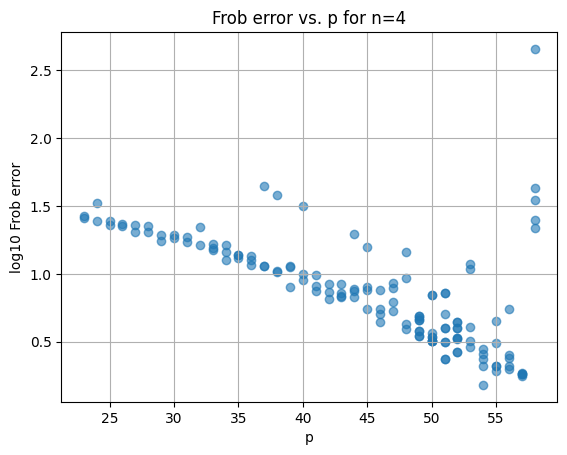

In [ ]:
#@title prompt: plot all the entries in the results list having n=4, with the x axis being p and the y axis being the max error

n_to_plot = 4 #@param
error_to_plot = "Frob error" #@param ["max error", "Frob error"]

# Assuming 'results' is a list of dictionaries as defined in the provided code
n_results = [result for result in results if result["n"] == n_to_plot]

# Extract p and max_error values
p_values = [result["p"] for result in n_results]
max_error_values = np.log10([result[error_to_plot] for result in n_results])

# Create the plot
plt.scatter(p_values, max_error_values, marker='o', alpha=0.6)
plt.xlabel("p")
plt.ylabel("log10 " + error_to_plot)
plt.title(f"{error_to_plot} vs. p for n={n_to_plot}")
plt.grid(True)
plt.show()


In [ ]:
# results = [result for result in results if result["Frob error"] < 1e2]